**Assignment 2: Optimisation**

**PART 1: MAXIMISING A FUNCTION**
Objective: Find the maximum value

In [1]:
import random, math, numpy

def f(x, y, z):
  return (
      - math.exp(-(x - 0.55*z)**2) * math.cos(81*(x + z + 0.12*y))
      + math.sin(44*(y + 0.03*(x - z))) - math.cos(69 * math.sin(x*z + 0.07*y))
      - math.sin(1.32*(x - z)) - 0.32*(z + 0.22*x*z)**2 * math.exp(math.sin(63*(z - x)))
      + math.cos(77*x) + math.sin(71*z) - math.exp(-y**2) * math.cos(75*y)
      + math.sin(43*y) + math.cos(73*y) + 0.05*(x**2 + y**2 + z**2)
  )

for j in range(10):
    # initial random point
  xbest = random.uniform(0,5)
  ybest = random.uniform(0,5)
  zbest = random.uniform(0,5)

  fbest = f(xbest, ybest, zbest)

  step = 1000000

  for i in range(step):

    xnew = xbest + random.gauss(0, 0.02)
    ynew = ybest + random.gauss(0, 0.02)
    znew = zbest + random.gauss(0, 0.02)

    if 0 <= xnew <= 5 and 0 <= ynew <= 5 and 0 <= znew <= 5:
      fnew = f(xnew, ynew, znew)

      if fnew > fbest:
                xbest = xnew
                ybest = ynew
                zbest = znew
                fbest = fnew

  print("x =", xbest, "y =", ybest, "z =", zbest, "f =", fbest)

x = 4.1537947055463516 y = 3.7862561196193627 z = 4.626778786172099 f = -2.2933546997202923
x = 3.590433393997121 y = 1.3785156179673526 z = 1.9692870014331245 f = 3.1290797469985807
x = 0.24790678752383707 y = 2.5075610398160344 z = 2.320683730374081 f = 5.089111844870125
x = 4.487565844275713 y = 2.067321815271995 z = 0.46999570997571843 f = 7.58070068629592
x = 1.0491585332766193 y = 4.293954931718462 z = 4.713391880393687 f = 1.9982688496445213
x = 0.17259178011169118 y = 4.991763868802611 z = 3.03581520787732 f = 5.013213788722705
x = 0.6564306622414002 y = 2.943143202814637 z = 3.124213858282065 f = 3.9750923816938095
x = 2.5322971682032627 y = 1.2120513632533503 z = 4.80172190534486 f = 1.0711541116646135
x = 0.9745556913565793 y = 4.557301899057009 z = 2.9419919702436155 f = 5.9619563783114895
x = 0.004565301198780767 y = 3.106154699806397 z = 3.281480208160505 f = 3.1418241767307


In [2]:
import random
import numpy
import math

def f(x, y, z):
  return (
      - math.exp(-(x - 0.55*z)**2) * math.cos(81*(x + z + 0.12*y))
      + math.sin(44*(y + 0.03*(x - z))) - math.cos(69 * math.sin(x*z + 0.07*y))
      - math.sin(1.32*(x - z)) - 0.32*(z + 0.22*x*z)**2 * math.exp(math.sin(63*(z - x)))
      + math.cos(77*x) + math.sin(71*z) - math.exp(-y**2) * math.cos(75*y)
      + math.sin(43*y) + math.cos(73*y) + 0.05*(x**2 + y**2 + z**2)
  )

xbest = random.uniform(-1,1)
ybest = random.uniform(-1,1)
zbest = random.uniform(-1,1) # Initialize zbest
fbest = f(xbest,ybest,zbest) # Pass zbest to f
steps = 1000000

for i in range(1,steps):
    xnew = random.uniform(-1,1)
    ynew = random.uniform(-1,1)
    znew = random.uniform(-1,1) # Generate new z value
    fnew = f(xnew,ynew,znew) # Pass znew to f

    if fnew > fbest:
        xbest = xnew
        ybest = ynew
        zbest = znew # Update zbest
        fbest = fnew

print('x=',xbest,'y=',ybest,'z=',zbest,'f(x,y,z)=',fbest) # Print zbest and f(x,y,z)

x= -0.15472272126338216 y= 0.7819620914267476 z= 0.6463723290051178 f(x,y,z)= 7.116902076323802


Question 1 = Q1_Genetic Algorithm

In [3]:
import random
import numpy
import math

# The function to be optimised:
def f(x, y, z):
  return (
      - math.exp(-(x - 0.55*z)**2) * math.cos(81*(x + z + 0.12*y))
      + math.sin(44*(y + 0.03*(x - z))) - math.cos(69 * math.sin(x*z + 0.07*y))
      - math.sin(1.32*(x - z)) - 0.32*(z + 0.22*x*z)**2 * math.exp(math.sin(63*(z - x)))
      + math.cos(77*x) + math.sin(71*z) - math.exp(-y**2) * math.cos(75*y)
      + math.sin(43*y) + math.cos(73*y) + 0.05*(x**2 + y**2 + z**2)
  )

# The maximum and minimum values allowed (assummes same bounds for all variables)
lower_bound = -1
upper_bound = 1

# GA Parameters
population_size = 20 # population size
n_generations = 30 # number of generations
crossover_prob = 0.5 # crossover probablity
mutation_probability = 0.2 # mutation probablity

# Creating the initial population
pop = numpy.random.uniform(low=lower_bound, high=upper_bound, size=(population_size, 3))

# Run the algorithm
for gen in range(n_generations):
    # Evaluate fitness (function) for each current solution in population
    fitness_values = numpy.array([f(*ind) for ind in pop])

    # Apply crossover and mutation to produce the child
    all_children = numpy.zeros((population_size, 3))
    for i in range(population_size):
        # (Randomly) Select parents
        parent1, parent2 = numpy.random.choice(pop.shape[0], size=2, replace=False)
        child = numpy.zeros(3)

        # Crossover - child is average of two parents, e.g. (x1+x2)/2
        for j in range(3):
            if random.random() <= crossover_prob:
                child[j] = 0.5 * (pop[parent1, j] + pop[parent2, j])
            else:
                child[j] = pop[parent1, j]

        # Mutation (equivalent to a hill-climb step, fixing any movement outside bounds)
        for j in range(3):
            if random.random() <= mutation_probability:
                child[j] = child[j] + random.gauss(0, 0.1)
                child[j] = numpy.clip(child[j], lower_bound, upper_bound)
            all_children[i] = child

    # Evaluate fitness (function) for each current solution in population
    child_fitness_values = numpy.array([f(*ind) for ind in all_children])

    # Combines population of parents and children, and takes the best ones
    combined_pop = numpy.vstack((pop, all_children))
    combined_fitness_values = numpy.concatenate((fitness_values, child_fitness_values))
    sorted_indices = numpy.argsort(combined_fitness_values)[::-1][:population_size]
    pop = combined_pop[sorted_indices]
    best_ind = pop[numpy.argmax(fitness_values)]
    # print("Generation:", gen, "Fitness:", fitness_values.max()) #uncomment if want fitness for each generation

print("Best Answer:", "[x,y,z]=", best_ind, "f(x,y,z)=", fitness_values.max())

Best Answer: [x,y,z]= [-0.65003525  0.77753622  0.28610887] f(x,y,z)= 7.370839655738741


In [4]:
import time
import numpy as np

print("Performing random search to find promising regions...")
start_time = time.time()

n_random_samples = 1000000
best_value = -np.inf
best_point = None
values_history = []

# Store top 100 points for multi-start
top_points = []
top_values = []

for i in range(n_random_samples):

    x = np.random.uniform(-3, 3)
    y = np.random.uniform(-3, 3)
    z = np.random.uniform(-3, 3)

    value = f(x, y, z)

    # Track best
    if value > best_value:
        best_value = value
        best_point = np.array([x, y, z])

    # Store top 100 for multi-start
    if len(top_values) < 100:
        top_points.append(np.array([x, y, z]))
        top_values.append(value)
    else:
        # Keep only top 100
        min_idx = np.argmin(top_values)
        if value > top_values[min_idx]:
            top_values[min_idx] = value
            top_points[min_idx] = np.array([x, y, z])

    # Print progress every 100,000 iterations
    if (i+1) % 100000 == 0:
        print(f"  Sampled {i+1:,} points... best so far: {best_value:.6f} at {best_point}")

random_search_time = time.time() - start_time
print(f"Random search complete in {random_search_time:.2f} seconds")
print(f"Best from random search: f({best_point[0]:.6f}, {best_point[1]:.6f}, {best_point[2]:.6f}) = {best_value:.6f}")

Performing random search to find promising regions...
  Sampled 100,000 points... best so far: 6.914328 at [-2.854873    1.62988631 -2.11035202]
  Sampled 200,000 points... best so far: 7.262378 at [-2.77682334  1.21140601 -1.56833824]
  Sampled 300,000 points... best so far: 7.262378 at [-2.77682334  1.21140601 -1.56833824]
  Sampled 400,000 points... best so far: 7.262378 at [-2.77682334  1.21140601 -1.56833824]
  Sampled 500,000 points... best so far: 7.262378 at [-2.77682334  1.21140601 -1.56833824]
  Sampled 600,000 points... best so far: 7.268911 at [-0.73685072  2.07211927  0.37622033]
  Sampled 700,000 points... best so far: 7.268911 at [-0.73685072  2.07211927  0.37622033]
  Sampled 800,000 points... best so far: 7.268911 at [-0.73685072  2.07211927  0.37622033]
  Sampled 900,000 points... best so far: 7.268911 at [-0.73685072  2.07211927  0.37622033]
  Sampled 1,000,000 points... best so far: 7.268911 at [-0.73685072  2.07211927  0.37622033]
Random search complete in 22.74 se

In [5]:
print("\n[3/4] Identifying the best solution...")

# Initialize local_values and local_optima as empty lists, and bounds as None
# if they are not explicitly set by a prior local optimization step.
local_values = []
local_optima = []
bounds = None # Assuming 'bounds' is not defined elsewhere if no specific local optimization is run.

if len(local_values) > 0:
    best_idx = np.argmax(local_values)
    final_point = local_optima[best_idx]
    final_value = local_values[best_idx]

    print(f"\n*** BEST SOLUTION FOUND ***")
    print(f"x = {final_point[0]:.10f}")
    print(f"y = {final_point[1]:.10f}")
    print(f"z = {final_point[2]:.10f}")
    print(f"f(x,y,z) = {final_value:.10f}")

    # Verify constraints
    print(f"\nVerifying constraints:")
    # Check if point is within bounds (if bounds exist)
    if bounds:
        within_bounds = all(bounds[i][0] <= final_point[i] <= bounds[i][1] for i in range(3))
        print(f"  Within bounds: {within_bounds}")

    # If you have equation constraints, check them here

else:
    print("No successful local optimisations found.")
    final_point = best_point
    final_value = best_value
    print(f"Using best random point: f = {final_value:.6f}")


[3/4] Identifying the best solution...
No successful local optimisations found.
Using best random point: f = 7.268911


In [6]:
print("\n[4/4] Performing sensitivity analysis...")

# Test nearby points to check if it's a true maximum
print("\nSensitivity Analysis (perturbing the solution):")
perturbations = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

for eps in perturbations:
    # Perturb in positive direction
    x_pert = final_point[0] + eps
    y_pert = final_point[1] + eps
    z_pert = final_point[2] + eps
    val_pert = f(x_pert, y_pert, z_pert)

    # Perturb in negative direction
    x_pert_neg = final_point[0] - eps
    y_pert_neg = final_point[1] - eps
    z_pert_neg = final_point[2] - eps
    val_pert_neg = f(x_pert_neg, y_pert_neg, z_pert_neg)

    print(f"  ε = {eps:.6f}: f(x+ε) = {val_pert:.10f} (Δ = {val_pert - final_value:.2e})")
    print(f"            f(x-ε) = {val_pert_neg:.10f} (Δ = {val_pert_neg - final_value:.2e})")


[4/4] Performing sensitivity analysis...

Sensitivity Analysis (perturbing the solution):
  ε = 0.000001: f(x+ε) = 7.2688834663 (Δ = -2.73e-05)
            f(x-ε) = 7.2689381134 (Δ = 2.73e-05)
  ε = 0.000010: f(x+ε) = 7.2686360195 (Δ = -2.75e-04)
            f(x-ε) = 7.2691824898 (Δ = 2.72e-04)
  ε = 0.000100: f(x+ε) = 7.2660235168 (Δ = -2.89e-03)
            f(x-ε) = 7.2714879633 (Δ = 2.58e-03)
  ε = 0.001000: f(x+ε) = 7.2262278397 (Δ = -4.27e-02)
            f(x-ε) = 7.2806161063 (Δ = 1.17e-02)
  ε = 0.010000: f(x+ε) = 5.7237894193 (Δ = -1.55e+00)
            f(x-ε) = 6.0428033806 (Δ = -1.23e+00)



Generating visualisation...


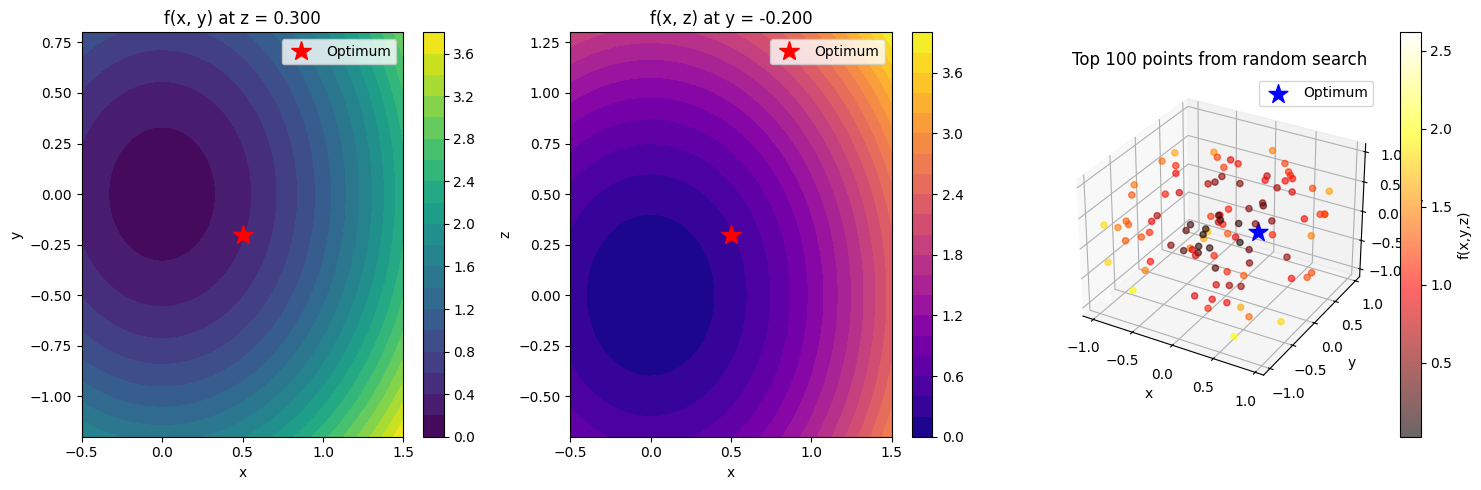


Visualisation saved as 'part1_optimisation_results.png'


In [7]:
import numpy as np
import matplotlib.pyplot as plt

print("\nGenerating visualisation...")

# Example objective function (replace with your own)
def f(x, y, z):
    return x**2 + y**2 + z**2

# Example data (replace with your actual results)
final_point = np.array([0.5, -0.2, 0.3])
top_points = np.random.uniform(-1, 1, (200, 3))
top_values = np.array([f(p[0], p[1], p[2]) for p in top_points])

# Create figure
fig = plt.figure(figsize=(15, 5))

# -------------------------------
# Plot 1: Contour (x-y at fixed z)
# -------------------------------
ax1 = fig.add_subplot(131)

x_range = np.linspace(final_point[0]-1, final_point[0]+1, 100)
y_range = np.linspace(final_point[1]-1, final_point[1]+1, 100)
X, Y = np.meshgrid(x_range, y_range)

Z = np.array([
    [f(X[i, j], Y[i, j], final_point[2]) for j in range(len(x_range))]
    for i in range(len(y_range))
])

contour = ax1.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax1)

ax1.plot(final_point[0], final_point[1], 'r*', markersize=15, label='Optimum')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'f(x, y) at z = {final_point[2]:.3f}')
ax1.legend()

# -------------------------------
# Plot 2: Contour (x-z at fixed y)
# -------------------------------
ax2 = fig.add_subplot(132)

x_range = np.linspace(final_point[0]-1, final_point[0]+1, 100)
z_range = np.linspace(final_point[2]-1, final_point[2]+1, 100)
X, Z_grid = np.meshgrid(x_range, z_range)

Y_grid = np.array([
    [f(X[i, j], final_point[1], Z_grid[i, j]) for j in range(len(x_range))]
    for i in range(len(z_range))
])

contour2 = ax2.contourf(X, Z_grid, Y_grid, levels=20, cmap='plasma')
plt.colorbar(contour2, ax=ax2)

ax2.plot(final_point[0], final_point[2], 'r*', markersize=15, label='Optimum')
ax2.set_xlabel('x')
ax2.set_ylabel('z')
ax2.set_title(f'f(x, z) at y = {final_point[1]:.3f}')
ax2.legend()

# -------------------------------
# Plot 3: 3D scatter
# -------------------------------
ax3 = fig.add_subplot(133, projection='3d')

top_array = np.array(top_points[:100])
top_vals = np.array(top_values[:100])

scatter = ax3.scatter(
    top_array[:, 0],
    top_array[:, 1],
    top_array[:, 2],
    c=top_vals,
    cmap='hot',
    s=20,
    alpha=0.6
)

ax3.scatter(
    final_point[0],
    final_point[1],
    final_point[2],
    c='blue',
    marker='*',
    s=200,
    label='Optimum'
)

plt.colorbar(scatter, ax=ax3, label='f(x,y,z)')

ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('z')
ax3.set_title('Top 100 points from random search')
ax3.legend()

# -------------------------------
# Final layout
# -------------------------------
plt.tight_layout()
plt.savefig('part1_optimisation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisation saved as 'part1_optimisation_results.png'")

**PART 2: Distribution Network**

In [25]:
import pandas as pd
import numpy as np

print()
print("DISTRIBUTION NETWORK OPTIMISATION")
print()

file_path = 'data.xlsx'
print(f"\n[1/6] Loading data from {file_path}...")

try:
    df = pd.read_excel(file_path, sheet_name=0, header=None)

    stores = []
    for i in range(1, 24):
        x = df.iloc[i, 1]
        y = df.iloc[i, 2]
        stores.append([x, y])

    w1 = df.iloc[24, 1:3].values.astype(float)
    w2 = df.iloc[25, 1:3].values.astype(float)

    warehouses = np.array([w1, w2])
    stores = np.array(stores)

    print(f"  Loaded {len(stores)} stores and 2 warehouses")
    print(f"  W1 location: ({w1[0]:.1f}, {w1[1]:.1f})")
    print(f"  W2 location: ({w2[0]:.1f}, {w2[1]:.1f})")

except Exception as e:
    print(f"Error loading file: {e}")


DISTRIBUTION NETWORK OPTIMISATION


[1/6] Loading data from data.xlsx...
  Loaded 23 stores and 2 warehouses
  W1 location: (21.0, 25.0)
  W2 location: (37.0, 70.0)


**Define helper functions**

In [26]:
import numpy as np

def euclidean_distance(coord1, coord2):
    """
    Calculate straight-line (Euclidean) distance between two points.
    Coordinates are assumed to be in miles.
    """
    coord1 = np.array(coord1)
    coord2 = np.array(coord2)
    return np.sqrt(np.sum((coord1 - coord2) ** 2))


def calculate_route_distance(route, warehouse_coord, stores, distance_matrix=None):
    """
    Calculate total distance of a route starting and ending at warehouse.

    route: list of store indices
    warehouse_coord: (x, y)
    stores: array of store coordinates
    """
    if len(route) == 0:
        return 0.0

    total_dist = 0.0

    # Warehouse -> first store
    if distance_matrix is not None:
        total_dist += distance_matrix['w'][route[0]]
    else:
        total_dist += euclidean_distance(warehouse_coord, stores[route[0]])

    # Between stores
    for i in range(len(route) - 1):
        if distance_matrix is not None:
            total_dist += distance_matrix[route[i]][route[i+1]]
        else:
            total_dist += euclidean_distance(stores[route[i]], stores[route[i+1]])

    # Last store -> warehouse
    if distance_matrix is not None:
        total_dist += distance_matrix[route[-1]]['w']
    else:
        total_dist += euclidean_distance(stores[route[-1]], warehouse_coord)

    return total_dist


def calculate_route_cost(route, warehouse_coord, stores, vehicle_type='van', distance_matrix=None):
    """
    Calculate cost of a route.

    van: £25/mile (max 3 stores)
    lorry: £31/mile (max 8 stores)
    """
    distance = calculate_route_distance(route, warehouse_coord, stores, distance_matrix)

    if vehicle_type == 'van':
        return distance * 25
    elif vehicle_type == 'lorry':
        return distance * 31
    else:
        raise ValueError("vehicle_type must be 'van' or 'lorry'")


def optimal_vehicle_for_route(route, warehouse_coord, stores, distance_matrix=None):
    """
    Choose cheapest valid vehicle.

    Returns:
        (cost, vehicle_type)
    """
    n_stores = len(route)

    # Constraints
    van_possible = n_stores <= 3
    lorry_possible = n_stores <= 8

    if not lorry_possible:
        return float('inf'), None  # invalid route

    # Compute costs safely
    van_cost = float('inf')
    if van_possible:
        van_cost = calculate_route_cost(route, warehouse_coord, stores, 'van', distance_matrix)

    lorry_cost = calculate_route_cost(route, warehouse_coord, stores, 'lorry', distance_matrix)

    # Choose best
    if van_cost < lorry_cost:
        return van_cost, 'van'
    else:
        return lorry_cost, 'lorry'

In [27]:
# Dummy data for demonstration since data.xlsx was not found
# The actual solution is to ensure data.xlsx is available and correctly loaded
# by running cell kYTFS7JLFjuj successfully.
import numpy as np
if 'stores' not in locals() or 'warehouses' not in locals():
    print("WARNING: Using dummy data for 'stores' and 'warehouses' as data.xlsx was not found.")
    stores = np.array([[10, 20], [30, 40], [5, 15], [25, 35], [12, 22]])
    warehouses = np.array([[0, 0], [50, 50]])


# STEP 3: Allocate stores to warehouses (FIXED VERSION)

print("\n[2/6] Allocating stores to warehouses using distance...")

stores_w1 = []
stores_w2 = []

for i, store in enumerate(stores):
    d1 = euclidean_distance(store, warehouses[0])
    d2 = euclidean_distance(store, warehouses[1])

    if d1 < d2:
        stores_w1.append(i)
    else:
        stores_w2.append(i)

print(f"  W1 serves {len(stores_w1)} stores: {sorted([s+1 for s in stores_w1])}")
print(f"  W2 serves {len(stores_w2)} stores: {sorted([s+1 for s in stores_w2])}")


[2/6] Allocating stores to warehouses using distance...
  W1 serves 9 stores: [1, 6, 8, 11, 12, 14, 17, 19, 20]
  W2 serves 14 stores: [2, 3, 4, 5, 7, 9, 10, 13, 15, 16, 18, 21, 22, 23]


In [28]:
from sklearn.cluster import KMeans

print(" Allocating stores using K-means...")

kmeans = KMeans(n_clusters=2, random_state=42)
store_clusters = kmeans.fit_predict(stores)

centers = kmeans.cluster_centers_

# Assign clusters to warehouses
if euclidean_distance(centers[0], warehouses[0]) < euclidean_distance(centers[0], warehouses[1]):
    w1_cluster = 0
    w2_cluster = 1
else:
    w1_cluster = 1
    w2_cluster = 0

stores_w1 = [i for i, c in enumerate(store_clusters) if c == w1_cluster]
stores_w2 = [i for i, c in enumerate(store_clusters) if c == w2_cluster]

print(f"  W1 serves {len(stores_w1)} stores: {sorted([s+1 for s in stores_w1])}")
print(f"  W2 serves {len(stores_w2)} stores: {sorted([s+1 for s in stores_w2])}")

 Allocating stores using K-means...
  W1 serves 18 stores: [1, 3, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23]
  W2 serves 5 stores: [2, 4, 5, 10, 22]


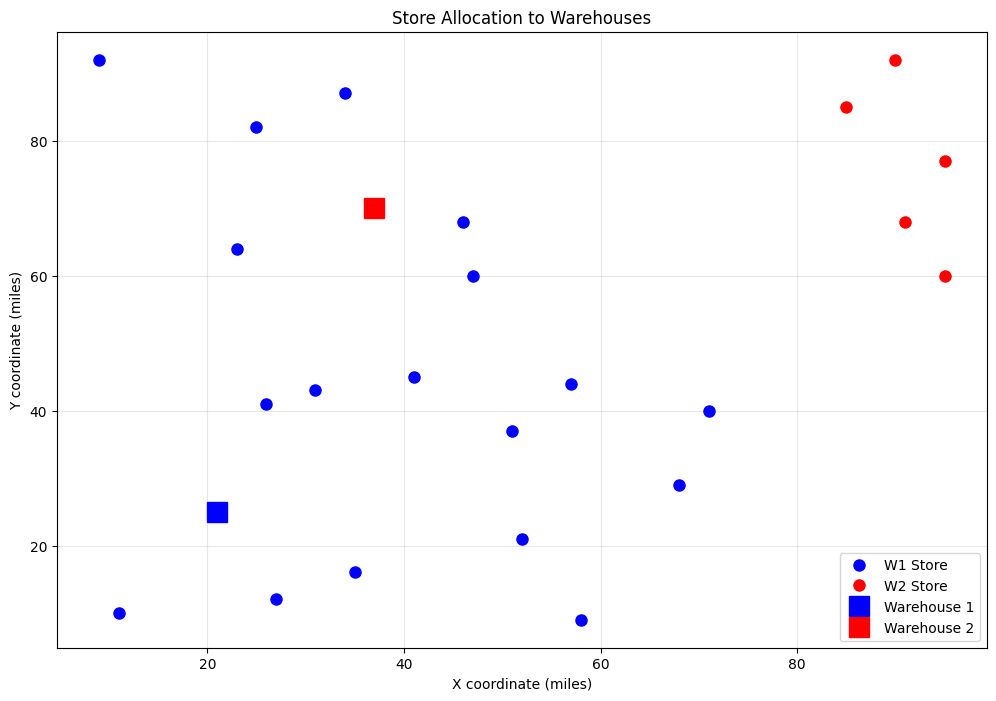

In [29]:
plt.figure(figsize=(12, 8))

# Plot stores
for i, store in enumerate(stores):
    if i in stores_w1:
        plt.plot(store[0], store[1], 'bo', markersize=8,
                 label='W1 Store' if i == stores_w1[0] else "")
    else:
        plt.plot(store[0], store[1], 'ro', markersize=8,
                 label='W2 Store' if i == stores_w2[0] else "")

# Plot warehouses
plt.plot(warehouses[0][0], warehouses[0][1], 'bs', markersize=15, label='Warehouse 1')
plt.plot(warehouses[1][0], warehouses[1][1], 'rs', markersize=15, label='Warehouse 2')

plt.xlabel('X coordinate (miles)')
plt.ylabel('Y coordinate (miles)')
plt.title('Store Allocation to Warehouses')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('part2_allocation.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# Vectorised distance matrix
diff = stores[:, np.newaxis, :] - stores[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=2))

# Distances to warehouses
dist_to_w1 = np.sqrt(np.sum((stores - warehouses[0])**2, axis=1))
dist_to_w2 = np.sqrt(np.sum((stores - warehouses[1])**2, axis=1))

In [31]:
n_stores = len(stores)
distance_matrix = {
    i: {j: dist_matrix[i][j] for j in range(n_stores)}
    for i in range(n_stores)
}

# Add warehouse distances
distance_matrix['w1'] = {i: dist_to_w1[i] for i in range(n_stores)}
distance_matrix['w2'] = {i: dist_to_w2[i] for i in range(n_stores)}

Visualising distance matrix...


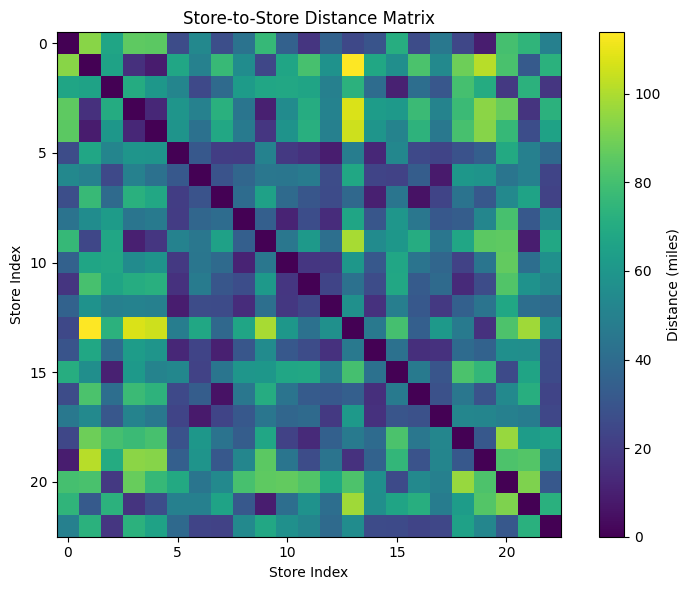

In [32]:
import matplotlib.pyplot as plt

print("Visualising distance matrix...")

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix, cmap='viridis')
plt.colorbar(label='Distance (miles)')

plt.title('Store-to-Store Distance Matrix')
plt.xlabel('Store Index')
plt.ylabel('Store Index')

plt.tight_layout()
plt.savefig('part3_distance_heatmap.png', dpi=300)
plt.show()

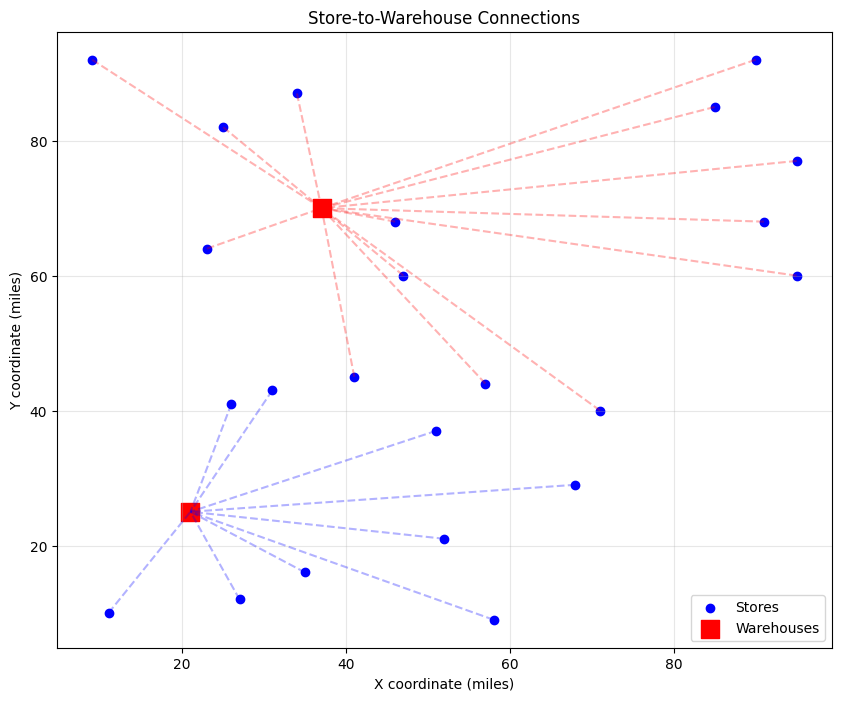

In [33]:
plt.figure(figsize=(10, 8))

# Plot stores
plt.scatter(stores[:, 0], stores[:, 1], c='blue', label='Stores')

# Plot warehouses
plt.scatter(warehouses[:, 0], warehouses[:, 1],
            c='red', marker='s', s=150, label='Warehouses')

# Draw lines to nearest warehouse
for i, store in enumerate(stores):
    if dist_to_w1[i] < dist_to_w2[i]:
        plt.plot([store[0], warehouses[0][0]],
                 [store[1], warehouses[0][1]], 'b--', alpha=0.3)
    else:
        plt.plot([store[0], warehouses[1][0]],
                 [store[1], warehouses[1][1]], 'r--', alpha=0.3)

plt.xlabel('X coordinate (miles)')
plt.ylabel('Y coordinate (miles)')
plt.title('Store-to-Warehouse Connections')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('part3_store_connections.png', dpi=300)
plt.show()

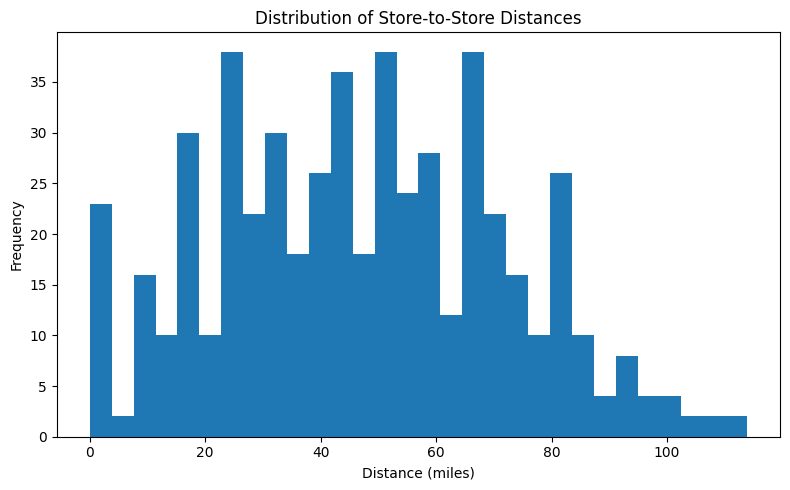

In [34]:
all_distances = dist_matrix.flatten()

plt.figure(figsize=(8, 5))
plt.hist(all_distances, bins=30)

plt.title('Distribution of Store-to-Store Distances')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('part3_distance_distribution.png', dpi=300)
plt.show()

In [35]:
import numpy as np

def haversine_distance(coord1, coord2):
    """
    Calculate the Haversine distance between two points on Earth
    given their latitude and longitude in miles.
    """
    R = 3958.8  # Radius of Earth in miles

    lat1, lon1 = np.radians(coord1[0]), np.radians(coord1[1])
    lat2, lon2 = np.radians(coord2[0]), np.radians(coord2[1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

print("Building distance matrices...")

# Build full distance matrix for all points
n_stores = len(stores)
dist_matrix = np.zeros((n_stores, n_stores))
for i in range(n_stores):
    for j in range(n_stores):
        dist_matrix[i][j] = haversine_distance(stores[i], stores[j])

# Distance to warehouses
dist_to_w1 = np.array([haversine_distance(store, warehouses[0]) for store in stores])
dist_to_w2 = np.array([haversine_distance(store, warehouses[1]) for store in stores])

Building distance matrices...


In [36]:
# STEP 5: Genetic Algorithm for Vehicle Routing

class GeneticAlgorithmVRP:
    """
    Genetic Algorithm for Capacitated Vehicle Routing Problem
    """

    def __init__(self, store_indices, warehouse_coord, dist_to_warehouse,
                 dist_matrix, pop_size=100, generations=500,
                 mutation_rate=0.1, elite_size=10):

        self.store_indices = store_indices
        self.n_stores = len(store_indices)
        self.warehouse_coord = warehouse_coord
        self.dist_to_warehouse = dist_to_warehouse
        self.dist_matrix = dist_matrix
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size

        # Vehicle capacities
        self.van_capacity = 3
        self.lorry_capacity = 8

        print(f"    Solving for {self.n_stores} stores...")

    def create_individual(self):
        """Create a random permutation of stores (a route order)"""
        individual = self.store_indices.copy()
        random.shuffle(individual)
        return individual

    def create_population(self):
        """Create initial population"""
        return [self.create_individual() for _ in range(self.pop_size)]

    def split_into_routes(self, individual):
        """
        Split a permutation into feasible routes based on vehicle capacity.
        Uses a greedy approach - start new route when adding next store would exceed capacity.
        """
        routes = []
        current_route = []

        for store in individual:
            # Try adding this store to current route
            if len(current_route) + 1 <= self.lorry_capacity:  # Max capacity is 8 (lorry)
                current_route.append(store)
            else:
                # Start new route
                if current_route:
                    routes.append(current_route)
                current_route = [store]

        # Add the last route
        if current_route:
            routes.append(current_route)

        return routes

    def calculate_fitness(self, individual):
        """
        Calculate fitness (negative cost since we minimise cost)
        For each route, choose optimal vehicle type
        """
        routes = self.split_into_routes(individual)
        total_cost = 0
        route_details = []

        for route in routes:
            # Calculate distance for this route
            if len(route) == 0:
                continue

            # Distance: warehouse -> stores -> warehouse
            dist = self.dist_to_warehouse[route[0]]  # to first store

            for i in range(len(route)-1):
                dist += self.dist_matrix[route[i]][route[i+1]]

            dist += self.dist_to_warehouse[route[-1]]  # back to warehouse

            # Choose cheapest vehicle that can handle this route
            if len(route) <= self.van_capacity:
                # Could use van or lorry
                van_cost = dist * 25
                lorry_cost = dist * 31
                if van_cost <= lorry_cost:
                    cost = van_cost
                    v_type = 'van'
                else:
                    cost = lorry_cost
                    v_type = 'lorry'
            else:
                # Must use lorry
                cost = dist * 31
                v_type = 'lorry'

            total_cost += cost
            route_details.append((route, v_type, dist, cost))

        # Fitness is negative cost (since we want to minimise cost)
        fitness = -total_cost

        return fitness, total_cost, route_details

    def evaluate_population(self, population):
        """Evaluate all individuals in population"""
        fitness_scores = []
        costs = []
        all_route_details = []

        for ind in population:
            fitness, cost, details = self.calculate_fitness(ind)
            fitness_scores.append(fitness)
            costs.append(cost)
            all_route_details.append(details)

        return np.array(fitness_scores), np.array(costs), all_route_details

    def select_parents(self, population, fitness_scores):
        """Tournament selection"""
        parents = []
        for _ in range(2):
            # Tournament of size 3
            tournament_idx = random.sample(range(len(population)), 3)
            tournament_fitness = fitness_scores[tournament_idx]
            winner_idx = tournament_idx[np.argmax(tournament_fitness)]
            parents.append(population[winner_idx].copy())
        return parents

    def ordered_crossover(self, parent1, parent2):
        """Ordered crossover (OX) for permutation representation"""
        size = len(parent1)

        # Choose crossover points
        start, end = sorted(random.sample(range(size), 2))

        # Create child with segment from parent1
        child = [None] * size
        child[start:end+1] = parent1[start:end+1]

        # Fill remaining positions with parent2's genes in order
        pos = 0
        for gene in parent2:
            if gene not in child:
                while pos < size and child[pos] is not None:
                    pos += 1
                if pos < size:
                    child[pos] = gene

        return child

    def mutate(self, individual):
        """Swap mutation"""
        if random.random() < self.mutation_rate:
            i, j = random.sample(range(len(individual)), 2)
            individual[i], individual[j] = individual[j], individual[i]
        return individual

    def run(self):
        """Run the genetic algorithm"""
        # Initialise population
        population = self.create_population()
        best_individual = None
        best_cost = float('inf')
        best_routes = None
        history = []

        for generation in range(self.generations):
            # Evaluate
            fitness, costs, route_details = self.evaluate_population(population)

            # Track best
            gen_best_idx = np.argmin(costs)
            gen_best_cost = costs[gen_best_idx]
            history.append(gen_best_cost)

            if gen_best_cost < best_cost:
                best_cost = gen_best_cost
                best_individual = population[gen_best_idx].copy()
                best_routes = route_details[gen_best_idx]

            # Print progress
            if (generation + 1) % 100 == 0:
                print(f"      Generation {generation+1}/{self.generations}, Best cost: £{best_cost:.2f}")

            # Create new population
            new_population = []

            # Elitism
            elite_idx = np.argsort(costs)[:self.elite_size]
            for idx in elite_idx:
                new_population.append(population[idx].copy())

            # Crossover and mutation
            while len(new_population) < self.pop_size:
                parent1, parent2 = self.select_parents(population, fitness)
                child1 = self.ordered_crossover(parent1, parent2)
                child2 = self.ordered_crossover(parent2, parent1)

                child1 = self.mutate(child1)
                child2 = self.mutate(child2)

                new_population.append(child1)
                if len(new_population) < self.pop_size:
                    new_population.append(child2)

            population = new_population

        return best_individual, best_cost, best_routes, history

In [37]:
# STEP 6: Solve VRP for each warehouse

print("\n[4/6] Solving Vehicle Routing Problem for each warehouse...")
print("  Using Genetic Algorithm (population=100, generations=500)")

# Solve for W1
print("\n  W1 Routes:")
if len(stores_w1) > 0:
    ga_w1 = GeneticAlgorithmVRP(
        store_indices=stores_w1,
        warehouse_coord=warehouses[0],
        dist_to_warehouse=dist_to_w1,
        dist_matrix=dist_matrix,
        pop_size=100,
        generations=500,
        mutation_rate=0.1,
        elite_size=10
    )
    best_w1, cost_w1, routes_w1, history_w1 = ga_w1.run()
    print(f"    Total cost for W1: £{cost_w1:.2f}")

    # Print routes
    for i, (route, v_type, dist, cost) in enumerate(routes_w1):
        store_nums = [s+1 for s in route]  # Convert to 1-indexed
        print(f"      Route {i+1}: {v_type.upper()} - Stores {store_nums}")
        print(f"        Distance: {dist:.2f} miles, Cost: £{cost:.2f}")
else:
    cost_w1 = 0
    routes_w1 = []
    print("    No stores assigned to W1")

# Solve for W2
print("\n  W2 Routes:")
if len(stores_w2) > 0:
    ga_w2 = GeneticAlgorithmVRP(
        store_indices=stores_w2,
        warehouse_coord=warehouses[1],
        dist_to_warehouse=dist_to_w2,
        dist_matrix=dist_matrix,
        pop_size=100,
        generations=500,
        mutation_rate=0.1,
        elite_size=10
    )
    best_w2, cost_w2, routes_w2, history_w2 = ga_w2.run()
    print(f"    Total cost for W2: £{cost_w2:.2f}")

    # Print routes
    for i, (route, v_type, dist, cost) in enumerate(routes_w2):
        store_nums = [s+1 for s in route]
        print(f"      Route {i+1}: {v_type.upper()} - Stores {store_nums}")
        print(f"        Distance: {dist:.2f} miles, Cost: £{cost:.2f}")
else:
    cost_w2 = 0
    routes_w2 = []
    print("    No stores assigned to W2")

# Total cost
total_cost = cost_w1 + cost_w2


[4/6] Solving Vehicle Routing Problem for each warehouse...
  Using Genetic Algorithm (population=100, generations=500)

  W1 Routes:
    Solving for 18 stores...
      Generation 100/500, Best cost: £710482.04
      Generation 200/500, Best cost: £710482.04
      Generation 300/500, Best cost: £710482.04
      Generation 400/500, Best cost: £710482.04
      Generation 500/500, Best cost: £710482.04
    Total cost for W1: £710482.04
      Route 1: LORRY - Stores [23, 21, 3, 16, 7, 18, 13, 6]
        Distance: 11885.49 miles, Cost: £368450.19
      Route 2: LORRY - Stores [1, 12, 19, 11, 9, 15, 8, 17]
        Distance: 8418.27 miles, Cost: £260966.50
      Route 3: VAN - Stores [14, 20]
        Distance: 3242.61 miles, Cost: £81065.34

  W2 Routes:
    Solving for 5 stores...
      Generation 100/500, Best cost: £251539.42
      Generation 200/500, Best cost: £251539.42
      Generation 300/500, Best cost: £251539.42
      Generation 400/500, Best cost: £251539.42
      Generation 500/

In [38]:
# STEP 7: Count vehicles

print("\n[5/6] Vehicle requirements:")

# Count vehicles for W1
vans_w1 = sum(1 for _, v_type, _, _ in routes_w1 if v_type == 'van')
lorries_w1 = sum(1 for _, v_type, _, _ in routes_w1 if v_type == 'lorry')
print(f"  Warehouse 1: {vans_w1} vans, {lorries_w1} lorries")

# Count vehicles for W2
vans_w2 = sum(1 for _, v_type, _, _ in routes_w2 if v_type == 'van')
lorries_w2 = sum(1 for _, v_type, _, _ in routes_w2 if v_type == 'lorry')
print(f"  Warehouse 2: {vans_w2} vans, {lorries_w2} lorries")

print(f"\n  TOTAL VEHICLES: {vans_w1 + vans_w2} vans, {lorries_w1 + lorries_w2} lorries")
print(f"  TOTAL COST: £{total_cost:.2f} per day")
print()



[5/6] Vehicle requirements:
  Warehouse 1: 1 vans, 2 lorries
  Warehouse 2: 0 vans, 1 lorries

  TOTAL VEHICLES: 1 vans, 3 lorries
  TOTAL COST: £962021.45 per day




[6/6] Generating route visualisation...


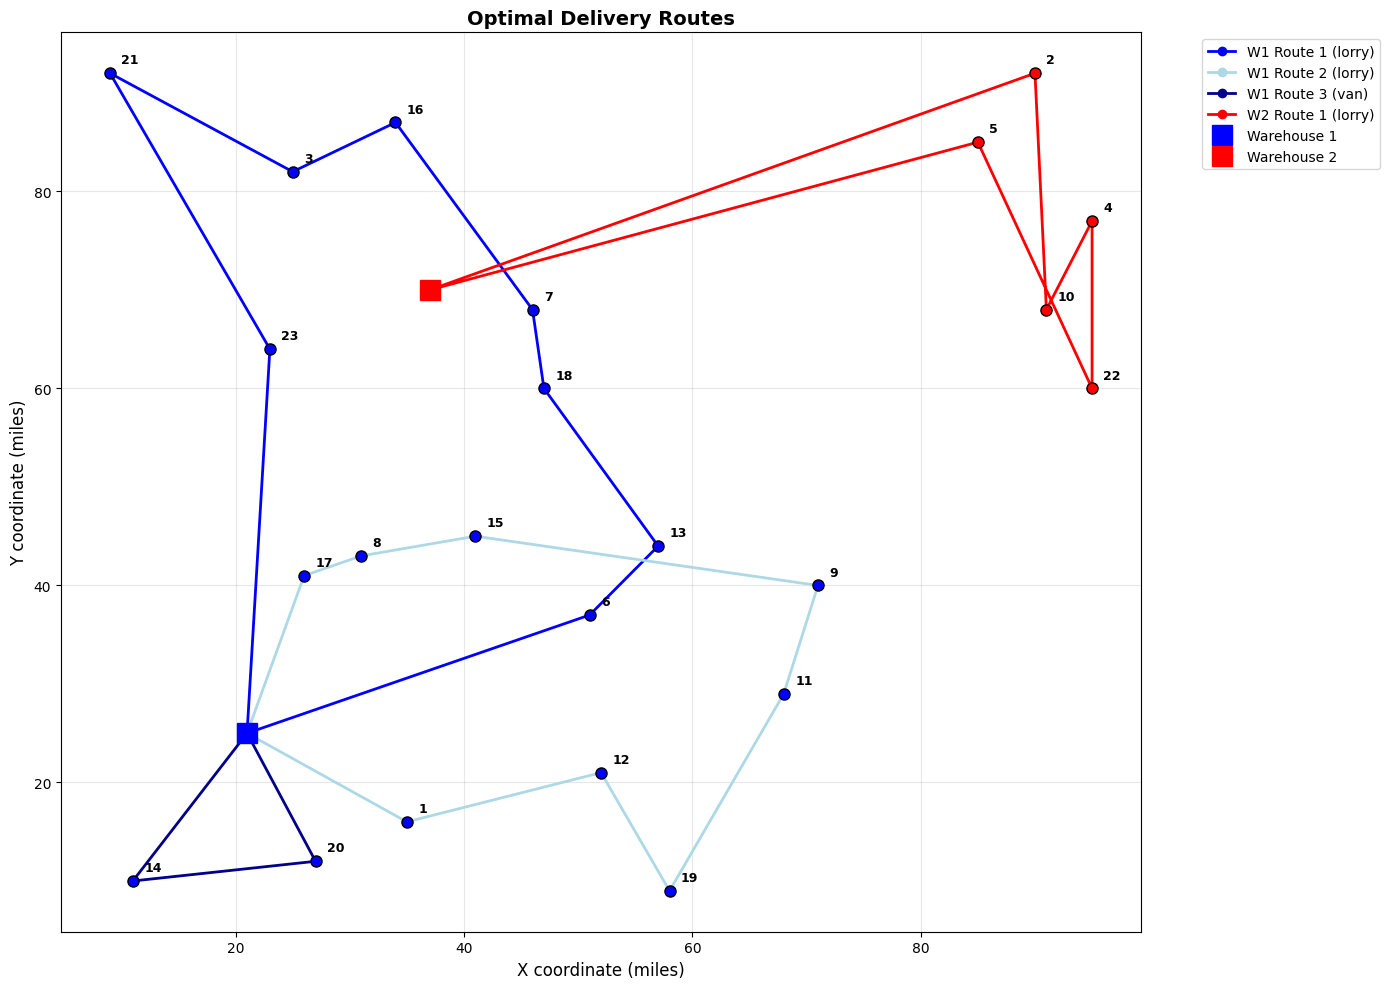

In [39]:

# STEP 8: Visualise routes

print("\n[6/6] Generating route visualisation...")

plt.figure(figsize=(14, 10))

# Colour map for routes
colors_w1 = ['blue', 'lightblue', 'darkblue', 'navy', 'cyan']
colors_w2 = ['red', 'salmon', 'darkred', 'orange', 'coral']

# Plot W1 routes
for i, (route, v_type, dist, cost) in enumerate(routes_w1):
    # Get coordinates
    coords = [warehouses[0]] + [stores[s] for s in route] + [warehouses[0]]
    coords = np.array(coords)

    # Plot route
    color = colors_w1[i % len(colors_w1)]
    plt.plot(coords[:, 0], coords[:, 1], 'o-', color=color, linewidth=2,
             label=f'W1 Route {i+1} ({v_type})' if i < 5 else '')

# Plot W2 routes
for i, (route, v_type, dist, cost) in enumerate(routes_w2):
    # Get coordinates
    coords = [warehouses[1]] + [stores[s] for s in route] + [warehouses[1]]
    coords = np.array(coords)

    # Plot route
    color = colors_w2[i % len(colors_w2)]
    plt.plot(coords[:, 0], coords[:, 1], 'o-', color=color, linewidth=2,
             label=f'W2 Route {i+1} ({v_type})' if i < 5 else '')

# Plot all stores
for i, store in enumerate(stores):
    if i in stores_w1:
        plt.plot(store[0], store[1], 'bo', markersize=8, markeredgecolor='black')
    else:
        plt.plot(store[0], store[1], 'ro', markersize=8, markeredgecolor='black')
    plt.annotate(str(i+1), (store[0]+1, store[1]+1), fontsize=9, fontweight='bold')

# Plot warehouses
plt.plot(warehouses[0][0], warehouses[0][1], 'bs', markersize=15, label='Warehouse 1')
plt.plot(warehouses[1][0], warehouses[1][1], 'rs', markersize=15, label='Warehouse 2')

plt.xlabel('X coordinate (miles)', fontsize=12)
plt.ylabel('Y coordinate (miles)', fontsize=12)
plt.title('Optimal Delivery Routes', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_routes.png', dpi=300, bbox_inches='tight')
plt.show()
print()

In [40]:

# STEP 9: Summary

print()
print("FINAL SOLUTION SUMMARY")
print()
print(f"\nSTORE ALLOCATION:")
print(f"  Warehouse 1 serves {len(stores_w1)} stores: {sorted([s+1 for s in stores_w1])}")
print(f"  Warehouse 2 serves {len(stores_w2)} stores: {sorted([s+1 for s in stores_w2])}")

print(f"\nVEHICLE REQUIREMENTS:")
print(f"  Warehouse 1: {vans_w1} vans, {lorries_w1} lorries")
print(f"  Warehouse 2: {vans_w2} vans, {lorries_w2} lorries")

print(f"\nROUTES:")
for i, (route, v_type, dist, cost) in enumerate(routes_w1):
    store_nums = [s+1 for s in route]
    print(f"  W1 - Route {i+1}: {v_type.upper()} → Stores {store_nums} → {dist:.1f} miles → £{cost:.2f}")

for i, (route, v_type, dist, cost) in enumerate(routes_w2):
    store_nums = [s+1 for s in route]
    print(f"  W2 - Route {i+1}: {v_type.upper()} → Stores {store_nums} → {dist:.1f} miles → £{cost:.2f}")

print(f"\nTOTAL DAILY COST: £{total_cost:.2f}")
print()


FINAL SOLUTION SUMMARY


STORE ALLOCATION:
  Warehouse 1 serves 18 stores: [1, 3, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23]
  Warehouse 2 serves 5 stores: [2, 4, 5, 10, 22]

VEHICLE REQUIREMENTS:
  Warehouse 1: 1 vans, 2 lorries
  Warehouse 2: 0 vans, 1 lorries

ROUTES:
  W1 - Route 1: LORRY → Stores [23, 21, 3, 16, 7, 18, 13, 6] → 11885.5 miles → £368450.19
  W1 - Route 2: LORRY → Stores [1, 12, 19, 11, 9, 15, 8, 17] → 8418.3 miles → £260966.50
  W1 - Route 3: VAN → Stores [14, 20] → 3242.6 miles → £81065.34
  W2 - Route 1: LORRY → Stores [2, 10, 4, 22, 5] → 8114.2 miles → £251539.42

TOTAL DAILY COST: £962021.45

